In [1]:
# ============================================================
# PHASE 4.1 — BIOLOGICAL VALIDATION + PATHWAY ENRICHMENT
# ============================================================

!pip install -q gprofiler-official

In [2]:
# ============================================================
# IMPORTS
# ============================================================

import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from gprofiler import GProfiler

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 220)

In [3]:
# ============================================================
# PATHS
# ============================================================

import os
from pathlib import Path
import pandas as pd
from google.colab import drive

try:
    drive.mount('/content/drive')
except ValueError:
    print("Drive đã được kết nối từ trước.")

PROJECT_DIR = Path("/content/drive/MyDrive/Project_Protein")

# Previous Phase 4 output
PHASE4_DIR = PROJECT_DIR / "model" / "phase4_biological_validation_preparation"
PHASE4_RESULT_DIR = PHASE4_DIR / "results"
PHASE4_GENE_LIST_DIR = PHASE4_DIR / "gene_lists"
PHASE4_REPORT_DIR = PHASE4_DIR / "reports"

# New Phase 4.1 output
PHASE4_1_DIR = PROJECT_DIR / "model" / "phase4_1_biological_validation_enrichment"
RESULT_DIR = PHASE4_1_DIR / "results"
ENRICHMENT_DIR = PHASE4_1_DIR / "enrichment_results"
FIGURE_DIR = PHASE4_1_DIR / "figures"
REPORT_DIR = PHASE4_1_DIR / "reports"

for folder in [
    PHASE4_1_DIR,
    RESULT_DIR,
    ENRICHMENT_DIR,
    FIGURE_DIR,
    REPORT_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Phase 4.1 output:", PHASE4_1_DIR)
print("Input gene list dir:", PHASE4_GENE_LIST_DIR)

Mounted at /content/drive
Phase 4.1 output: /content/drive/MyDrive/Project_Protein/model/phase4_1_biological_validation_enrichment
Input gene list dir: /content/drive/MyDrive/Project_Protein/model/phase4_biological_validation_preparation/gene_lists


In [4]:
# ============================================================
# LOAD GENE LISTS FROM PHASE 4.0B
# ============================================================

gene_list_files = {
    "top_50_combined_predictions": PHASE4_GENE_LIST_DIR / "gene_symbols_top_50_combined_predictions.txt",
    "top_true_positives": PHASE4_GENE_LIST_DIR / "gene_symbols_top_true_positives.txt",
    "high_confidence_false_positives": PHASE4_GENE_LIST_DIR / "gene_symbols_high_confidence_false_positives.txt",
    "high_confidence_false_negatives": PHASE4_GENE_LIST_DIR / "gene_symbols_high_confidence_false_negatives.txt",
    "combined_rescued_genes": PHASE4_GENE_LIST_DIR / "gene_symbols_combined_rescued_genes.txt",
    "both_wrong_genes": PHASE4_GENE_LIST_DIR / "gene_symbols_both_wrong_genes.txt"
}


def read_gene_list(path):
    if not path.exists():
        print("Missing:", path)
        return []

    with open(path, "r") as f:
        genes = [line.strip() for line in f.readlines()]

    genes = [g for g in genes if g != ""]
    genes = list(dict.fromkeys(genes))  # preserve order and remove duplicates

    return genes


gene_lists = {}

for list_name, path in gene_list_files.items():
    genes = read_gene_list(path)
    gene_lists[list_name] = genes
    print(f"{list_name}: {len(genes)} genes")

print("\nPreview top_50_combined_predictions:")
print(gene_lists["top_50_combined_predictions"][:20])

top_50_combined_predictions: 50 genes
top_true_positives: 86 genes
high_confidence_false_positives: 40 genes
high_confidence_false_negatives: 49 genes
combined_rescued_genes: 18 genes
both_wrong_genes: 74 genes

Preview top_50_combined_predictions:
['FOXN3', 'DACH1', 'NDUFB2', 'ETV1', 'NEUROD1', 'INSR', 'GAD1', 'CPEB3', 'TSHZ3', 'DYRK2', 'NDUFV1', 'ADRB1', 'CACNA1D', 'HHEX', 'TCF12', 'DNMT3A', 'BCL11B', 'MEIS1', 'NDUFB3', 'SLC5A1']


In [5]:
# ============================================================
# LOAD PREDICTION TABLES FROM PHASE 4.0B
# ============================================================

all_predictions_path = PHASE4_RESULT_DIR / "phase4_0B_official_combined_svm_all_test_predictions.csv"
candidate_table_path = PHASE4_RESULT_DIR / "phase4_0B_biological_validation_candidate_table.csv"
master_table_path = PHASE4_RESULT_DIR / "phase4_0A_final_master_comparison_table.csv"

assert all_predictions_path.exists(), f"Missing: {all_predictions_path}"
assert candidate_table_path.exists(), f"Missing: {candidate_table_path}"
assert master_table_path.exists(), f"Missing: {master_table_path}"

all_predictions_df = pd.read_csv(all_predictions_path)
candidate_table_df = pd.read_csv(candidate_table_path)
master_comparison_df = pd.read_csv(master_table_path)

print("all_predictions_df:", all_predictions_df.shape)
print("candidate_table_df:", candidate_table_df.shape)
print("master_comparison_df:", master_comparison_df.shape)

display(master_comparison_df.head(10))
display(all_predictions_df.head())

all_predictions_df: (271, 17)
candidate_table_df: (271, 19)
master_comparison_df: (10, 13)


,phase,branch,representation,embedding_policy,feature_type,model,selection_policy,threshold_policy,test_roc_auc,test_pr_auc,test_f1,test_mcc,main_note
0,3.1,Multimodal,ProtBERT SW + K3/K4/Basic,early fusion direct concatenation,protein embedding + genomic handcrafted,SVM RBF,validation ROC-AUC,default_0.5,0.7290,0.7573,0.6590,0.3438,Official multimodal integration model
1,3.1,Protein shared split,ProtBERT SW,shared split,protein foundation embedding,SVM RBF,validation ROC-AUC,default_0.5,0.7274,0.7433,0.6667,0.3215,Best protein-only model on shared Phase 3 split
2,2.2,Genomic regulatory,K3 + K4 + Basic,handcrafted TSS-proximal 2kbUp+500bpDown,genomic handcrafted k-mer + GC/CpG features,SVM RBF,diagnostic test comparison,default_0.5,0.6765,0.6504,0.6620,0.2933,"Diagnostic best genomic model, not official selection"
3,2.1,Genomic regulatory,K3 + K4 + Basic,handcrafted TSS-proximal 2kbUp+500bpDown,genomic handcrafted k-mer + GC/CpG features,Random Forest,validation ROC-AUC,default_0.5,0.6496,0.6327,0.6406,0.2557,Official genomic handcrafted model
4,1.2E,Protein,ProtBERT,sliding_window_1022_stride_1022,protein foundation embedding,Logistic Regression,validation ROC-AUC,default_0.5,0.6487,0.6551,0.5896,0.1941,Best protein ranking representation before shared split
5,1.2D,Protein,ProtBERT,truncated_1022,protein foundation embedding,Logistic Regression,validation ROC-AUC,default_0.5,0.6371,0.6423,0.6014,0.1943,ProtBERT truncated
6,1.2B,Protein,ESM2_t6_8M,sliding_window_1022_stride_1022,protein foundation embedding,Soft Voting,validation ROC-AUC,default_0.5,0.6277,0.6278,0.5870,0.1650,ESM-2 small sliding-window
7,1.2A,Protein,ESM2_t6_8M,truncated_1022,protein foundation embedding,Stacking,validation ROC-AUC,default_0.5,0.6202,0.6188,0.5926,0.1941,ESM-2 small truncated baseline
8,1.2C,Protein,ESM2_t12_35M,truncated_1022,protein foundation embedding,Soft Voting,validation ROC-AUC,default_0.5,0.5875,0.5942,0.5654,0.0995,Larger ESM-2 did not improve under truncation
9,1.1,Protein,AAC + Physchem,handcrafted,handcrafted protein descriptors,Random Forest,validation ROC-AUC,default_0.5,0.5520,0.5550,0.5390,0.0480,Protein handcrafted baseline


,gene_id,gene_symbol_protein,label_protein,protein_row_index,original_protein_split,gene_symbol_genomic,label_genomic,genomic_row_index,original_genomic_split,label_match,label,gene_symbol,true_label,combined_svm_score,combined_svm_pred,combined_error_type,combined_correct
0,ENSG00000053254,FOXN3,1,671,train,FOXN3,1,193,train,True,1,FOXN3,1,0.884630,1,TP,True
1,ENSG00000276644,DACH1,1,549,train,DACH1,1,919,train,True,1,DACH1,1,0.841229,1,TP,True
2,ENSG00000090266,NDUFB2,1,1719,test,NDUFB2,1,930,train,True,1,NDUFB2,1,0.831156,1,TP,True
3,ENSG00000006468,ETV1,1,1701,test,ETV1,1,540,train,True,1,ETV1,1,0.824098,1,TP,True
4,ENSG00000162992,NEUROD1,1,1726,test,NEUROD1,1,795,train,True,1,NEUROD1,1,0.818462,1,TP,True


In [6]:
# ============================================================
# BIOLOGICAL KEYWORD GROUPS FOR T2D RELEVANCE SCORING
# ============================================================

keyword_groups = {
    "diabetes_glucose_insulin": [
        "diabetes", "insulin", "glucose", "glycemic", "glycaemic",
        "glycolysis", "gluconeogenesis", "glucagon", "pancreatic",
        "pancreas", "islet", "beta cell", "beta-cell", "β-cell",
        "secretion", "homeostasis"
    ],

    "lipid_metabolism": [
        "lipid", "fatty acid", "cholesterol", "triglyceride",
        "lipoprotein", "adipose", "adipocyte", "ppar", "sterol"
    ],

    "mitochondria_energy": [
        "mitochond", "oxidative phosphorylation", "electron transport",
        "respiratory chain", "atp", "nad", "nadh", "oxidoreductase",
        "energy metabolism", "oxidation"
    ],

    "inflammation_immune": [
        "inflamm", "immune", "cytokine", "interleukin", "nf-kappa",
        "tnf", "macrophage", "leukocyte", "response to stress"
    ],

    "signaling_regulation": [
        "pi3k", "akt", "mapk", "ampk", "mtor", "wnt", "tgf",
        "calcium", "camp", "kinase", "phosphorylation",
        "transcription", "regulation of gene expression"
    ],

    "development_beta_cell": [
        "development", "differentiation", "endocrine", "neuron",
        "neurogenesis", "pancreas development", "islet development"
    ]
}


def score_biological_relevance(term_name):
    if pd.isna(term_name):
        return 0, []

    text = str(term_name).lower()

    matched_groups = []

    for group_name, keywords in keyword_groups.items():
        for kw in keywords:
            if kw.lower() in text:
                matched_groups.append(group_name)
                break

    matched_groups = sorted(list(set(matched_groups)))
    score = len(matched_groups)

    return score, matched_groups

In [7]:
# ============================================================
# INITIALIZE G:PROFILER
# ============================================================

gp = GProfiler(
    return_dataframe=True
)

print("g:Profiler initialized.")

g:Profiler initialized.


In [8]:
# ============================================================
# FUNCTION: RUN G:PROFILER ENRICHMENT
# ============================================================

def run_gprofiler_enrichment(
    gene_list,
    list_name,
    organism="hsapiens",
    sources=None,
    user_threshold=0.05
):
    """
    Run g:Profiler enrichment for one gene list.

    Recommended sources:
    GO:BP = biological process
    GO:MF = molecular function
    GO:CC = cellular component
    KEGG = KEGG pathways
    REAC = Reactome
    WP = WikiPathways
    HP = Human Phenotype
    """

    if sources is None:
        sources = ["GO:BP", "GO:MF", "GO:CC", "KEGG", "REAC", "WP", "HP"]

    clean_genes = [
        str(g).strip()
        for g in gene_list
        if pd.notna(g) and str(g).strip() != ""
    ]

    clean_genes = list(dict.fromkeys(clean_genes))

    print("=" * 100)
    print("Running g:Profiler:", list_name)
    print("n genes:", len(clean_genes))
    print("sources:", sources)

    if len(clean_genes) < 3:
        print("Skipped because gene list has fewer than 3 genes.")
        return pd.DataFrame()

    try:
        result_df = gp.profile(
            organism=organism,
            query=clean_genes,
            sources=sources,
            user_threshold=user_threshold,
            significance_threshold_method="g_SCS",
            no_evidences=False
        )

        if result_df is None or result_df.empty:
            print("No significant enrichment found.")
            return pd.DataFrame()

        result_df = result_df.copy()
        result_df["gene_list_name"] = list_name
        result_df["input_n_genes"] = len(clean_genes)
        result_df["input_genes"] = ";".join(clean_genes)

        # Make column names stable
        if "p_value" in result_df.columns:
            result_df["minus_log10_p_value"] = -np.log10(result_df["p_value"].replace(0, np.nextafter(0, 1)))

        # Add biological relevance score
        relevance_scores = result_df["name"].apply(score_biological_relevance)
        result_df["t2d_relevance_score"] = relevance_scores.apply(lambda x: x[0])
        result_df["matched_biological_groups"] = relevance_scores.apply(lambda x: ";".join(x[1]))

        # Count intersections
        if "intersections" in result_df.columns:
            result_df["intersection_size"] = result_df["intersections"].apply(
                lambda x: len(x) if isinstance(x, list) else 0
            )
        elif "intersection" in result_df.columns:
            result_df["intersection_size"] = result_df["intersection"].apply(
                lambda x: len(x) if isinstance(x, list) else 0
            )
        else:
            result_df["intersection_size"] = np.nan

        result_df = result_df.sort_values(
            by=["t2d_relevance_score", "p_value"],
            ascending=[False, True]
        ).reset_index(drop=True)

        print("Significant terms:", result_df.shape[0])

        return result_df

    except Exception as e:
        print("g:Profiler failed for:", list_name)
        print("Error:", repr(e))
        return pd.DataFrame()

In [9]:
# ============================================================
# RUN ENRICHMENT FOR ALL GENE LISTS
# ============================================================

ENRICHMENT_SOURCES = ["GO:BP", "GO:MF", "GO:CC", "KEGG", "REAC", "WP", "HP"]

all_enrichment_results = {}

for list_name, genes in gene_lists.items():
    result_df = run_gprofiler_enrichment(
        gene_list=genes,
        list_name=list_name,
        organism="hsapiens",
        sources=ENRICHMENT_SOURCES,
        user_threshold=0.05
    )

    all_enrichment_results[list_name] = result_df

    out_path = ENRICHMENT_DIR / f"gprofiler_enrichment_{list_name}.csv"
    result_df.to_csv(out_path, index=False)

    print("Saved:", out_path)

Running g:Profiler: top_50_combined_predictions
n genes: 50
sources: ['GO:BP', 'GO:MF', 'GO:CC', 'KEGG', 'REAC', 'WP', 'HP']
Significant terms: 102
Saved: /content/drive/MyDrive/Project_Protein/model/phase4_1_biological_validation_enrichment/enrichment_results/gprofiler_enrichment_top_50_combined_predictions.csv
Running g:Profiler: top_true_positives
n genes: 86
sources: ['GO:BP', 'GO:MF', 'GO:CC', 'KEGG', 'REAC', 'WP', 'HP']
Significant terms: 175
Saved: /content/drive/MyDrive/Project_Protein/model/phase4_1_biological_validation_enrichment/enrichment_results/gprofiler_enrichment_top_true_positives.csv
Running g:Profiler: high_confidence_false_positives
n genes: 40
sources: ['GO:BP', 'GO:MF', 'GO:CC', 'KEGG', 'REAC', 'WP', 'HP']
No significant enrichment found.
Saved: /content/drive/MyDrive/Project_Protein/model/phase4_1_biological_validation_enrichment/enrichment_results/gprofiler_enrichment_high_confidence_false_positives.csv
Running g:Profiler: high_confidence_false_negatives
n gene

In [10]:
# ============================================================
# COMBINE ALL ENRICHMENT RESULTS
# ============================================================

non_empty_results = [
    df for df in all_enrichment_results.values()
    if df is not None and not df.empty
]

if len(non_empty_results) > 0:
    all_enrichment_df = pd.concat(non_empty_results, ignore_index=True)
else:
    all_enrichment_df = pd.DataFrame()

print("All enrichment results:", all_enrichment_df.shape)

if not all_enrichment_df.empty:
    display(all_enrichment_df.head(30))

all_enrichment_path = RESULT_DIR / "phase4_1_all_gprofiler_enrichment_results.csv"
all_enrichment_df.to_csv(all_enrichment_path, index=False)

print("Saved:", all_enrichment_path)

All enrichment results: (281, 22)


,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents,intersections,evidences,gene_list_name,input_n_genes,input_genes,minus_log10_p_value,t2d_relevance_score,matched_biological_groups
0,KEGG,KEGG:00190,Oxidative phosphorylation,0.012901,True,Oxidative phosphorylation,136,34,5,8716,0.147059,0.036765,query_1,[KEGG:00000],"[NDUFB2, NDUFV1, NDUFB3, NDUFA7, NDUFB1]","[[KEGG], [KEGG], [KEGG], [KEGG], [KEGG]]",top_50_combined_predictions,50,FOXN3;DACH1;NDUFB2;ETV1;NEUROD1;INSR;GAD1;CPEB3;TSHZ3;DYRK2;NDUFV1;ADRB1;CACNA1D;HHEX;TCF12;DNMT3A;BCL11B;MEIS1;NDUFB3;SLC5A1;GALNT10;ATP1A2;GATD3;NFAT5;IGF2BP2;HMG20A;RHBDL3;ISL1;NDUFA7;RALY;ADCY9;ZC3H12C;PTPRM;ACAD...,1.889375,2,mitochondria_energy;signaling_regulation
1,WP,WP:WP623,Oxidative phosphorylation,0.014813,True,Oxidative phosphorylation,60,36,4,8899,0.111111,0.066667,query_1,[WP:000000],"[NDUFB2, NDUFV1, NDUFA7, NDUFB1]","[[WP], [WP], [WP], [WP]]",top_50_combined_predictions,50,FOXN3;DACH1;NDUFB2;ETV1;NEUROD1;INSR;GAD1;CPEB3;TSHZ3;DYRK2;NDUFV1;ADRB1;CACNA1D;HHEX;TCF12;DNMT3A;BCL11B;MEIS1;NDUFB3;SLC5A1;GALNT10;ATP1A2;GATD3;NFAT5;IGF2BP2;HMG20A;RHBDL3;ISL1;NDUFA7;RALY;ADCY9;ZC3H12C;PTPRM;ACAD...,1.829371,2,mitochondria_energy;signaling_regulation
2,GO:BP,GO:0006119,oxidative phosphorylation,0.030841,True,"""The phosphorylation of ADP to ATP that accompanies the oxidation of a metabolite through the operation of the respiratory chain. Oxidation of compounds establishes a proton gradient across the membrane, providing th...",146,47,5,20972,0.106383,0.034247,query_1,[GO:0009060],"[NDUFB2, NDUFV1, NDUFB3, NDUFA7, NDUFB1]","[[NAS], [IDA, IMP, IBA, NAS, IC, IEA], [TAS, NAS], [IBA, NAS, IEA], [NAS]]",top_50_combined_predictions,50,FOXN3;DACH1;NDUFB2;ETV1;NEUROD1;INSR;GAD1;CPEB3;TSHZ3;DYRK2;NDUFV1;ADRB1;CACNA1D;HHEX;TCF12;DNMT3A;BCL11B;MEIS1;NDUFB3;SLC5A1;GALNT10;ATP1A2;GATD3;NFAT5;IGF2BP2;HMG20A;RHBDL3;ISL1;NDUFA7;RALY;ADCY9;ZC3H12C;PTPRM;ACAD...,1.510876,2,mitochondria_energy;signaling_regulation
3,GO:BP,GO:0031016,pancreas development,0.049015,True,"""The process whose specific outcome is the progression of the pancreas over time, from its formation to the mature structure. The pancreas is an endoderm derived structure that produces precursors of digestive enzyme...",79,47,4,20972,0.085106,0.050633,query_1,[GO:0048513],"[NEUROD1, INSR, ISL1, PDX1]","[[ISS, IEA], [IEA], [ISS, IEA], [IDA, ISS, IBA, IEA]]",top_50_combined_predictions,50,FOXN3;DACH1;NDUFB2;ETV1;NEUROD1;INSR;GAD1;CPEB3;TSHZ3;DYRK2;NDUFV1;ADRB1;CACNA1D;HHEX;TCF12;DNMT3A;BCL11B;MEIS1;NDUFB3;SLC5A1;GALNT10;ATP1A2;GATD3;NFAT5;IGF2BP2;HMG20A;RHBDL3;ISL1;NDUFA7;RALY;ADCY9;ZC3H12C;PTPRM;ACAD...,1.309674,2,development_beta_cell;diabetes_glucose_insulin
4,GO:MF,GO:0008137,NADH dehydrogenase (ubiquinone) activity,0.000018,True,"""Catalysis of the reaction: NADH + ubiquinone + 5 H+(in) = NAD+ + ubiquinol + 4 H+(out)."" [RHEA:29091]",41,48,5,20208,0.104167,0.121951,query_1,"[GO:0009055, GO:0015078, GO:0015453, GO:0022853]","[NDUFB2, NDUFV1, NDUFB3, NDUFA7, NDUFB1]","[[NAS], [IDA, NAS, IEA], [TAS, NAS], [NAS], [TAS, NAS]]",top_50_combined_predictions,50,FOXN3;DACH1;NDUFB2;ETV1;NEUROD1;INSR;GAD1;CPEB3;TSHZ3;DYRK2;NDUFV1;ADRB1;CACNA1D;HHEX;TCF12;DNMT3A;BCL11B;MEIS1;NDUFB3;SLC5A1;GALNT10;ATP1A2;GATD3;NFAT5;IGF2BP2;HMG20A;RHBDL3;ISL1;NDUFA7;RALY;ADCY9;ZC3H12C;PTPRM;ACAD...,4.733166,1,mitochondria_energy
5,GO:CC,GO:0030964,NADH dehydrogenase complex,0.000021,True,"""An integral membrane complex that possesses NADH oxidoreductase activity. The complex is one of the components of the electron transport chain. It catalyzes the transfer of a pair of electrons from NADH to a quinone...",49,50,5,22155,0.100000,0.102041,query_1,"[GO:0098796, GO:1990204]","[NDUFB2, NDUFV1, NDUFB3, NDUFA7, NDUFB1]","[[IDA, IBA, NAS, IEA], [IDA, IMP, IBA, IEA], [IDA, IBA, NAS, IEA], [IDA, IBA, NAS, IEA], [IDA, IBA, NAS, IEA]]",top_50_combined_predictions,50,FOXN3;DACH1;NDUFB2;ETV1;NEU

Saved: /content/drive/MyDrive/Project_Protein/model/phase4_1_biological_validation_enrichment/results/phase4_1_all_gprofiler_enrichment_results.csv


In [11]:
# ============================================================
# EXTRACT T2D-RELEVANT ENRICHMENT TERMS
# ============================================================

if not all_enrichment_df.empty:
    t2d_relevant_terms_df = all_enrichment_df[
        all_enrichment_df["t2d_relevance_score"] > 0
    ].copy()

    t2d_relevant_terms_df = t2d_relevant_terms_df.sort_values(
        by=["t2d_relevance_score", "p_value"],
        ascending=[False, True]
    ).reset_index(drop=True)

    display(t2d_relevant_terms_df[[
        "gene_list_name",
        "source",
        "native",
        "name",
        "p_value",
        "t2d_relevance_score",
        "matched_biological_groups",
        "intersection_size"
    ]].head(50))

    t2d_relevant_path = RESULT_DIR / "phase4_1_t2d_relevant_enrichment_terms.csv"
    t2d_relevant_terms_df.to_csv(t2d_relevant_path, index=False)

    print("Saved:", t2d_relevant_path)
else:
    t2d_relevant_terms_df = pd.DataFrame()
    print("No enrichment result available.")

,gene_list_name,source,native,name,p_value,t2d_relevance_score,matched_biological_groups,intersection_size
0,top_true_positives,GO:BP,GO:0006119,oxidative phosphorylation,1.573991e-05,2,mitochondria_energy;signaling_regulation,9
1,top_true_positives,WP,WP:WP623,Oxidative phosphorylation,2.063590e-05,2,mitochondria_energy;signaling_regulation,7
2,top_true_positives,KEGG,KEGG:00190,Oxidative phosphorylation,2.258298e-05,2,mitochondria_energy;signaling_regulation,9
3,top_50_combined_predictions,KEGG,KEGG:00190,Oxidative phosphorylation,1.290106e-02,2,mitochondria_energy;signaling_regulation,5
4,top_50_combined_predictions,WP,WP:WP623,Oxidative phosphorylation,1.481252e-02,2,mitochondria_energy;signaling_regulation,4
5,top_50_combined_predictions,GO:BP,GO:0006119,oxidative phosphorylation,3.084071e-02,2,mitochondria_energy;signaling_regulation,5
6,top_50_combined_predictions,GO:BP,GO:0031016,pancreas development,4.901470e-02,2,development_beta_cell;diabetes_glucose_insulin,4
7,top_true_positives,GO:CC,GO:0045271,respiratory chain complex I,6.968994e-11,1,mitochondria_energy,9
8,top_true_positives,GO:CC,GO:0030964,NADH dehydrogenase complex,6.968994e-11,1,mitochondria_energy,9
9,top_true_positives,GO:MF,GO:0008137,NADH dehydrogenase (ubiquinone) activity,2.842241e-09,1,mitochondria_energy,8


Saved: /content/drive/MyDrive/Project_Protein/model/phase4_1_biological_validation_enrichment/results/phase4_1_t2d_relevant_enrichment_terms.csv


In [12]:
# ============================================================
# ENRICHMENT SUMMARY BY GENE LIST
# ============================================================

summary_records = []

for list_name, genes in gene_lists.items():
    df = all_enrichment_results.get(list_name, pd.DataFrame())

    if df is None or df.empty:
        summary_records.append({
            "gene_list_name": list_name,
            "n_input_genes": len(genes),
            "n_significant_terms": 0,
            "n_t2d_relevant_terms": 0,
            "best_p_value": np.nan,
            "top_term": None,
            "top_t2d_relevant_term": None
        })
        continue

    t2d_df = df[df["t2d_relevance_score"] > 0].copy()

    top_term = df.sort_values("p_value").iloc[0]["name"]

    if not t2d_df.empty:
        top_t2d_term = t2d_df.sort_values(
            by=["t2d_relevance_score", "p_value"],
            ascending=[False, True]
        ).iloc[0]["name"]
    else:
        top_t2d_term = None

    summary_records.append({
        "gene_list_name": list_name,
        "n_input_genes": len(genes),
        "n_significant_terms": df.shape[0],
        "n_t2d_relevant_terms": t2d_df.shape[0],
        "best_p_value": df["p_value"].min(),
        "top_term": top_term,
        "top_t2d_relevant_term": top_t2d_term
    })

enrichment_summary_df = pd.DataFrame(summary_records).sort_values(
    by=["n_t2d_relevant_terms", "n_significant_terms"],
    ascending=False
)

display(enrichment_summary_df)

summary_path = RESULT_DIR / "phase4_1_enrichment_summary_by_gene_list.csv"
enrichment_summary_df.to_csv(summary_path, index=False)

print("Saved:", summary_path)

,gene_list_name,n_input_genes,n_significant_terms,n_t2d_relevant_terms,best_p_value,top_term,top_t2d_relevant_term
1,top_true_positives,86,175,63,6.968994e-11,respiratory chain complex I,oxidative phosphorylation
0,top_50_combined_predictions,50,102,41,1.848562e-05,NADH dehydrogenase (ubiquinone) activity,Oxidative phosphorylation
3,high_confidence_false_negatives,49,3,0,4.795541e-02,Anterior uveitis,None
5,both_wrong_genes,74,1,0,1.069641e-02,regulation of toll-like receptor 3 signaling pathway,None
2,high_confidence_false_positives,40,0,0,NaN,None,None
4,combined_rescued_genes,18,0,0,NaN,None,None


Saved: /content/drive/MyDrive/Project_Protein/model/phase4_1_biological_validation_enrichment/results/phase4_1_enrichment_summary_by_gene_list.csv


In [13]:
# ============================================================
# TOP TERMS PER GENE LIST
# ============================================================

top_terms_records = []

for list_name, df in all_enrichment_results.items():
    if df is None or df.empty:
        continue

    top_df = df.sort_values(
        by=["p_value"],
        ascending=True
    ).head(15).copy()

    top_terms_records.append(top_df)

if len(top_terms_records) > 0:
    top_terms_per_list_df = pd.concat(top_terms_records, ignore_index=True)
else:
    top_terms_per_list_df = pd.DataFrame()

if not top_terms_per_list_df.empty:
    display(top_terms_per_list_df[[
        "gene_list_name",
        "source",
        "native",
        "name",
        "p_value",
        "t2d_relevance_score",
        "matched_biological_groups",
        "intersection_size"
    ]].head(100))

top_terms_path = RESULT_DIR / "phase4_1_top_15_terms_per_gene_list.csv"
top_terms_per_list_df.to_csv(top_terms_path, index=False)

print("Saved:", top_terms_path)

,gene_list_name,source,native,name,p_value,t2d_relevance_score,matched_biological_groups,intersection_size
0,top_50_combined_predictions,GO:MF,GO:0008137,NADH dehydrogenase (ubiquinone) activity,1.848562e-05,1,mitochondria_energy,5
1,top_50_combined_predictions,GO:CC,GO:0030964,NADH dehydrogenase complex,2.140703e-05,1,mitochondria_energy,5
2,top_50_combined_predictions,GO:CC,GO:0045271,respiratory chain complex I,2.140703e-05,1,mitochondria_energy,5
3,top_50_combined_predictions,GO:MF,GO:0000987,cis-regulatory region sequence-specific DNA binding,9.462702e-05,0,,14
4,top_50_combined_predictions,KEGG,KEGG:04723,Retrograde endocannabinoid signaling,1.051099e-04,0,,7
5,top_50_combined_predictions,GO:BP,GO:0009150,purine ribonucleotide metabolic process,1.235962e-04,0,,9
6,top_50_combined_predictions,GO:MF,GO:0022853,active monoatomic ion transmembrane transporter activity,1.435914e-04,0,,6
7,top_50_combined_predictions,GO:MF,GO:0015453,oxidoreduction-driven active transmembrane transporter activity,1.952541e-04,0,,5
8,top_50_combined_predictions,GO:BP,GO:0006120,"mitochondrial electron transport, NADH to ubiquinone",2.003820e-04,1,mitochondria_energy,5
9,top_50_combined_predictions,GO:BP,GO:0009259,ribonucleotide metabolic process,2.069548e-04,0,,9


Saved: /content/drive/MyDrive/Project_Protein/model/phase4_1_biological_validation_enrichment/results/phase4_1_top_15_terms_per_gene_list.csv


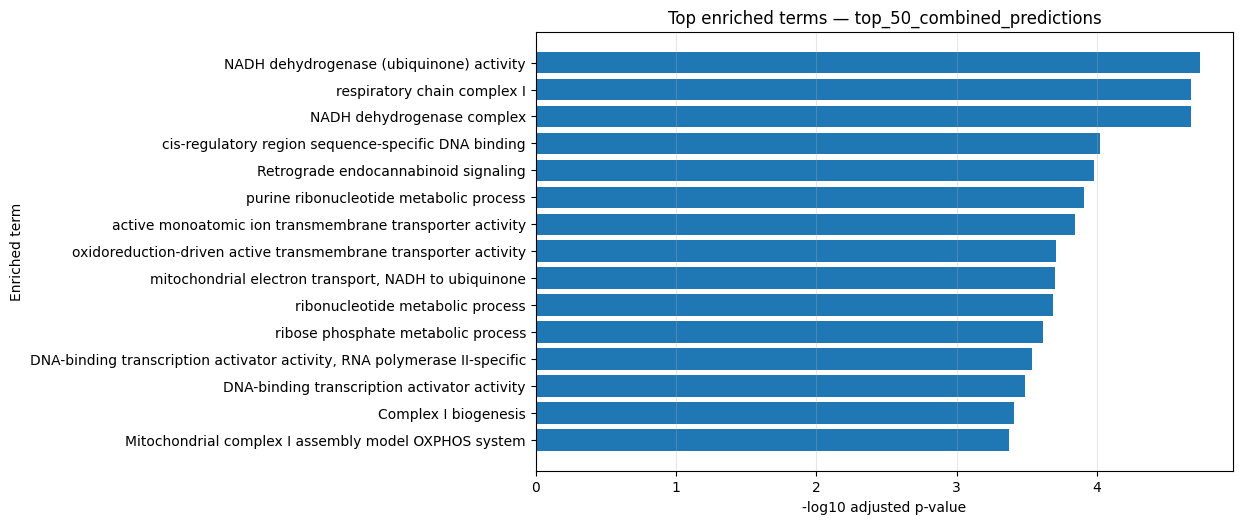

Saved: /content/drive/MyDrive/Project_Protein/model/phase4_1_biological_validation_enrichment/figures/phase4_1_top50_combined_predictions_enrichment.png


In [14]:
# ============================================================
# PLOT TOP ENRICHED TERMS FOR TOP 50 COMBINED PREDICTIONS
# ============================================================

def plot_top_enrichment_terms(df, list_name, top_n=15, output_path=None):
    if df is None or df.empty:
        print("No terms to plot for:", list_name)
        return

    plot_df = df.sort_values("p_value").head(top_n).copy()

    if "minus_log10_p_value" not in plot_df.columns:
        plot_df["minus_log10_p_value"] = -np.log10(plot_df["p_value"].replace(0, np.nextafter(0, 1)))

    plot_df = plot_df.sort_values("minus_log10_p_value", ascending=True)

    labels = plot_df["name"].astype(str)

    plt.figure(figsize=(9, max(5, 0.38 * len(plot_df))))
    plt.barh(labels, plot_df["minus_log10_p_value"])
    plt.xlabel("-log10 adjusted p-value")
    plt.ylabel("Enriched term")
    plt.title(f"Top enriched terms — {list_name}")
    plt.grid(axis="x", alpha=0.3)

    if output_path is not None:
        plt.savefig(output_path, dpi=300, bbox_inches="tight")

    plt.show()

    if output_path is not None:
        print("Saved:", output_path)


top50_enrichment_df = all_enrichment_results.get("top_50_combined_predictions", pd.DataFrame())

plot_top_enrichment_terms(
    df=top50_enrichment_df,
    list_name="top_50_combined_predictions",
    top_n=15,
    output_path=FIGURE_DIR / "phase4_1_top50_combined_predictions_enrichment.png"
)

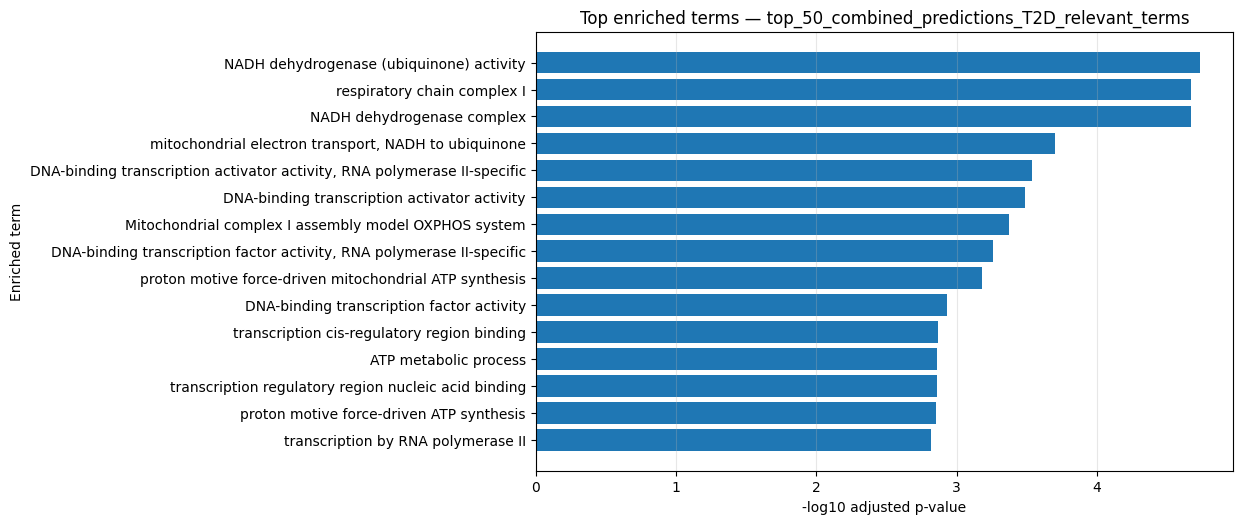

Saved: /content/drive/MyDrive/Project_Protein/model/phase4_1_biological_validation_enrichment/figures/phase4_1_top50_t2d_relevant_enrichment.png


In [15]:
# ============================================================
# PLOT T2D-RELEVANT TERMS FOR TOP 50 COMBINED PREDICTIONS
# ============================================================

if top50_enrichment_df is not None and not top50_enrichment_df.empty:
    top50_t2d_terms_df = top50_enrichment_df[
        top50_enrichment_df["t2d_relevance_score"] > 0
    ].copy()

    plot_top_enrichment_terms(
        df=top50_t2d_terms_df,
        list_name="top_50_combined_predictions_T2D_relevant_terms",
        top_n=15,
        output_path=FIGURE_DIR / "phase4_1_top50_t2d_relevant_enrichment.png"
    )
else:
    top50_t2d_terms_df = pd.DataFrame()
    print("No top50 enrichment results.")

In [16]:
# ============================================================
# CURATED T2D-RELATED GENE SETS FOR OVERLAP VALIDATION
# ============================================================

curated_gene_sets = {
    "known_T2D_GWAS_or_monogenic_related": [
        "TCF7L2", "PPARG", "KCNJ11", "ABCC8", "SLC30A8", "HHEX", "CDKAL1",
        "CDKN2A", "CDKN2B", "IGF2BP2", "FTO", "MTNR1B", "KCNQ1", "WFS1",
        "JAZF1", "THADA", "NOTCH2", "ADCY5", "IRS1", "GCK", "GCKR",
        "PDX1", "NEUROD1", "HNF1A", "HNF1B", "HNF4A", "PAX4", "INSR"
    ],

    "insulin_secretion_beta_cell": [
        "ABCC8", "KCNJ11", "GCK", "PDX1", "NEUROD1", "MAFA", "NKX2-2",
        "NKX6-1", "INS", "INSR", "SLC30A8", "CACNA1D", "CACNA1C",
        "GLP1R", "DPP4", "GAD1", "GAD2", "PCSK1", "PCSK2"
    ],

    "glucose_metabolism_transport": [
        "SLC2A1", "SLC2A2", "SLC2A4", "SLC5A1", "GCK", "G6PC",
        "G6PC2", "HK1", "HK2", "PFKM", "PKM", "LDHA", "LDHB",
        "GYS1", "GYS2", "PYGL", "PYGM"
    ],

    "lipid_metabolism_adipose": [
        "PPARG", "PPARA", "FABP4", "ADIPOQ", "LEP", "LEPR", "LPL",
        "APOA1", "APOA5", "APOB", "APOE", "SCD", "SCD5", "FASN",
        "ACACA", "ACACB", "CPT1A", "CPT2"
    ],

    "mitochondrial_oxphos": [
        "NDUFA1", "NDUFA2", "NDUFA3", "NDUFA4", "NDUFA7", "NDUFB1",
        "NDUFB2", "NDUFB3", "NDUFV1", "NDUFS1", "NDUFS2", "COX4I1",
        "COX5A", "ATP5F1A", "ATP5F1B", "UQCRC1", "UQCRC2"
    ],

    "inflammation_stress": [
        "TNF", "IL6", "IL1B", "NFKB1", "NFKBIA", "RELA", "JUN", "FOS",
        "STAT3", "SOCS3", "CRP", "MCP1", "CCL2", "TLR4"
    ]
}


def compute_overlap_with_curated_sets(query_genes, query_name, curated_sets):
    query_set = set([str(g).upper() for g in query_genes])

    records = []

    for set_name, curated_genes in curated_sets.items():
        curated_set = set([str(g).upper() for g in curated_genes])

        overlap = sorted(list(query_set & curated_set))

        records.append({
            "query_gene_list": query_name,
            "curated_set": set_name,
            "n_query_genes": len(query_set),
            "n_curated_genes": len(curated_set),
            "n_overlap": len(overlap),
            "overlap_fraction_query": len(overlap) / len(query_set) if len(query_set) > 0 else 0,
            "overlap_genes": ";".join(overlap)
        })

    return pd.DataFrame(records)


overlap_results = []

for list_name, genes in gene_lists.items():
    overlap_df = compute_overlap_with_curated_sets(
        query_genes=genes,
        query_name=list_name,
        curated_sets=curated_gene_sets
    )
    overlap_results.append(overlap_df)

curated_overlap_df = pd.concat(overlap_results, ignore_index=True)

curated_overlap_df = curated_overlap_df.sort_values(
    by=["n_overlap", "overlap_fraction_query"],
    ascending=False
)

display(curated_overlap_df)

curated_overlap_path = RESULT_DIR / "phase4_1_curated_t2d_gene_set_overlap.csv"
curated_overlap_df.to_csv(curated_overlap_path, index=False)

print("Saved:", curated_overlap_path)

,query_gene_list,curated_set,n_query_genes,n_curated_genes,n_overlap,overlap_fraction_query,overlap_genes
6,top_true_positives,known_T2D_GWAS_or_monogenic_related,86,28,8,0.093023,ABCC8;HHEX;IGF2BP2;INSR;KCNJ11;MTNR1B;NEUROD1;PDX1
7,top_true_positives,insulin_secretion_beta_cell,86,19,8,0.093023,ABCC8;CACNA1D;DPP4;GAD1;INSR;KCNJ11;NEUROD1;PDX1
1,top_50_combined_predictions,insulin_secretion_beta_cell,50,19,6,0.120000,CACNA1D;DPP4;GAD1;INSR;NEUROD1;PDX1
10,top_true_positives,mitochondrial_oxphos,86,17,6,0.069767,NDUFA2;NDUFA7;NDUFB1;NDUFB2;NDUFB3;NDUFV1
0,top_50_combined_predictions,known_T2D_GWAS_or_monogenic_related,50,28,5,0.100000,HHEX;IGF2BP2;INSR;NEUROD1;PDX1
4,top_50_combined_predictions,mitochondrial_oxphos,50,17,5,0.100000,NDUFA7;NDUFB1;NDUFB2;NDUFB3;NDUFV1
24,combined_rescued_genes,known_T2D_GWAS_or_monogenic_related,18,28,2,0.111111,ABCC8;MTNR1B
18,high_confidence_false_negatives,known_T2D_GWAS_or_monogenic_related,49,28,2,0.040816,PAX4;THADA
30,both_wrong_genes,known_T2D_GWAS_or_monogenic_related,74,28,2,0.027027,PAX4;THADA
25,combined_rescued_genes,insulin_secretion_beta_cell,18,19,1,0.055556,ABCC8


Saved: /content/drive/MyDrive/Project_Protein/model/phase4_1_biological_validation_enrichment/results/phase4_1_curated_t2d_gene_set_overlap.csv


In [17]:
# ============================================================
# VALIDATION STATUS FOR TOP 50 COMBINED PREDICTIONS
# ============================================================

top50_predictions_path = PHASE4_GENE_LIST_DIR / "phase4_0B_top_50_combined_svm_predicted_t2d_genes.csv"

if not top50_predictions_path.exists():
    # Fallback from result table if your file was saved in result dir instead
    top50_predictions_path = PHASE4_GENE_LIST_DIR / "phase4_0B_top_50_combined_svm_predicted_t2d_genes.csv"

top50_df = pd.read_csv(top50_predictions_path)

# Build reverse curated annotation
gene_to_curated_sets = defaultdict(list)

for set_name, genes in curated_gene_sets.items():
    for gene in genes:
        gene_to_curated_sets[str(gene).upper()].append(set_name)

top50_df["gene_symbol_upper"] = top50_df["gene_symbol"].astype(str).str.upper()

top50_df["curated_t2d_related_sets"] = top50_df["gene_symbol_upper"].apply(
    lambda g: ";".join(gene_to_curated_sets.get(g, []))
)

top50_df["has_curated_t2d_support"] = top50_df["curated_t2d_related_sets"] != ""

# Add rank
top50_df = top50_df.sort_values(
    by="combined_svm_score",
    ascending=False
).reset_index(drop=True)

top50_df["rank"] = np.arange(1, len(top50_df) + 1)

display(top50_df[[
    "rank",
    "gene_id",
    "gene_symbol",
    "true_label",
    "combined_svm_score",
    "combined_error_type",
    "has_curated_t2d_support",
    "curated_t2d_related_sets"
]].head(50))

top50_validation_path = RESULT_DIR / "phase4_1_top50_gene_curated_validation_status.csv"
top50_df.to_csv(top50_validation_path, index=False)

print("Saved:", top50_validation_path)

,rank,gene_id,gene_symbol,true_label,combined_svm_score,combined_error_type,has_curated_t2d_support,curated_t2d_related_sets
0,1,ENSG00000053254,FOXN3,1,0.884630,TP,False,
1,2,ENSG00000276644,DACH1,1,0.841229,TP,False,
2,3,ENSG00000090266,NDUFB2,1,0.831156,TP,True,mitochondrial_oxphos
3,4,ENSG00000006468,ETV1,1,0.824098,TP,False,
4,5,ENSG00000162992,NEUROD1,1,0.818462,TP,True,known_T2D_GWAS_or_monogenic_related;insulin_secretion_beta_cell
5,6,ENSG00000171105,INSR,1,0.817504,TP,True,known_T2D_GWAS_or_monogenic_related;insulin_secretion_beta_cell
6,7,ENSG00000128683,GAD1,1,0.813424,TP,True,insulin_secretion_beta_cell
7,8,ENSG00000107864,CPEB3,1,0.808824,TP,False,
8,9,ENSG00000121297,TSHZ3,1,0.808711,TP,False,
9,10,ENSG00000127334,DYRK2,1,0.805801,TP,False,


Saved: /content/drive/MyDrive/Project_Protein/model/phase4_1_biological_validation_enrichment/results/phase4_1_top50_gene_curated_validation_status.csv


In [18]:
# ============================================================
# TOP 50 VALIDATION SUPPORT SUMMARY
# ============================================================

top50_support_summary = {
    "n_top50_genes": len(top50_df),
    "n_true_positive": int((top50_df["combined_error_type"] == "TP").sum()),
    "n_false_positive": int((top50_df["combined_error_type"] == "FP").sum()),
    "n_with_curated_t2d_support": int(top50_df["has_curated_t2d_support"].sum()),
    "pct_with_curated_t2d_support": float(top50_df["has_curated_t2d_support"].mean() * 100),
    "supported_genes": ";".join(
        top50_df.loc[top50_df["has_curated_t2d_support"], "gene_symbol"].astype(str).tolist()
    )
}

top50_support_summary_df = pd.DataFrame([top50_support_summary])

display(top50_support_summary_df)

support_summary_path = RESULT_DIR / "phase4_1_top50_curated_support_summary.csv"
top50_support_summary_df.to_csv(support_summary_path, index=False)

print("Saved:", support_summary_path)

,n_top50_genes,n_true_positive,n_false_positive,n_with_curated_t2d_support,pct_with_curated_t2d_support,supported_genes
0,50,43,7,15,30.0,NDUFB2;NEUROD1;INSR;GAD1;NDUFV1;CACNA1D;HHEX;NDUFB3;SLC5A1;IGF2BP2;NDUFA7;SCD5;NDUFB1;DPP4;PDX1


Saved: /content/drive/MyDrive/Project_Protein/model/phase4_1_biological_validation_enrichment/results/phase4_1_top50_curated_support_summary.csv


In [19]:
# ============================================================
# BIOLOGICAL VALIDATION PRIORITY TABLE
# ============================================================

priority_df = top50_df.copy()

def assign_biological_validation_priority(row):
    if row["combined_error_type"] == "TP" and row["has_curated_t2d_support"]:
        return "high_priority_known_supported_TP"
    if row["combined_error_type"] == "TP" and not row["has_curated_t2d_support"]:
        return "potentially_novel_or_indirect_TP"
    if row["combined_error_type"] == "FP" and row["has_curated_t2d_support"]:
        return "label_missing_candidate_FP"
    if row["combined_error_type"] == "FP" and not row["has_curated_t2d_support"]:
        return "possible_false_positive_or_indirect"
    return "other"

priority_df["biological_validation_priority"] = priority_df.apply(
    assign_biological_validation_priority,
    axis=1
)

priority_df = priority_df.sort_values(
    by=["biological_validation_priority", "rank"],
    ascending=[True, True]
)

display(priority_df[[
    "rank",
    "gene_symbol",
    "true_label",
    "combined_svm_score",
    "combined_error_type",
    "has_curated_t2d_support",
    "curated_t2d_related_sets",
    "biological_validation_priority"
]].head(50))

priority_path = RESULT_DIR / "phase4_1_top50_biological_validation_priority_table.csv"
priority_df.to_csv(priority_path, index=False)

print("Saved:", priority_path)

,rank,gene_symbol,true_label,combined_svm_score,combined_error_type,has_curated_t2d_support,curated_t2d_related_sets,biological_validation_priority
2,3,NDUFB2,1,0.831156,TP,True,mitochondrial_oxphos,high_priority_known_supported_TP
4,5,NEUROD1,1,0.818462,TP,True,known_T2D_GWAS_or_monogenic_related;insulin_secretion_beta_cell,high_priority_known_supported_TP
5,6,INSR,1,0.817504,TP,True,known_T2D_GWAS_or_monogenic_related;insulin_secretion_beta_cell,high_priority_known_supported_TP
6,7,GAD1,1,0.813424,TP,True,insulin_secretion_beta_cell,high_priority_known_supported_TP
10,11,NDUFV1,1,0.804632,TP,True,mitochondrial_oxphos,high_priority_known_supported_TP
12,13,CACNA1D,1,0.798518,TP,True,insulin_secretion_beta_cell,high_priority_known_supported_TP
13,14,HHEX,1,0.798434,TP,True,known_T2D_GWAS_or_monogenic_related,high_priority_known_supported_TP
18,19,NDUFB3,1,0.778949,TP,True,mitochondrial_oxphos,high_priority_known_supported_TP
19,20,SLC5A1,1,0.772375,TP,True,glucose_metabolism_transport,high_priority_known_supported_TP
24,25,IGF2BP2,1,0.764528,TP,True,known_T2D_GWAS_or_monogenic_related,high_priority_known_supported_TP


Saved: /content/drive/MyDrive/Project_Protein/model/phase4_1_biological_validation_enrichment/results/phase4_1_top50_biological_validation_priority_table.csv


In [20]:
# ============================================================
# WRITE PHASE 4.1 BIOLOGICAL VALIDATION REPORT
# ============================================================

n_gene_lists = len(gene_lists)
n_enriched_lists = int((enrichment_summary_df["n_significant_terms"] > 0).sum())
n_t2d_relevant_lists = int((enrichment_summary_df["n_t2d_relevant_terms"] > 0).sum())

top50_n_supported = int(top50_support_summary["n_with_curated_t2d_support"])
top50_pct_supported = float(top50_support_summary["pct_with_curated_t2d_support"])
supported_genes = top50_support_summary["supported_genes"]

if not top50_t2d_terms_df.empty:
    top_t2d_terms_text = top50_t2d_terms_df[
        ["source", "native", "name", "p_value", "matched_biological_groups"]
    ].head(10).to_string(index=False)
else:
    top_t2d_terms_text = "No automatically keyword-matched T2D-relevant enrichment terms found for top 50 predictions."

report_text = f"""
# Phase 4.1 — Biological Validation and Pathway Enrichment Report

## Objective

Phase 4.1 evaluated the biological plausibility of the official multimodal prediction results.

The analysis focused on gene lists produced by the official Phase 3 model:

- Combined Protein+Genomic SVM RBF
- Protein representation: ProtBERT sliding-window embedding
- Genomic representation: K3/K4/Basic TSS-proximal regulatory features

The main gene lists evaluated were:

- Top 50 combined predictions
- Top true positives
- Combined-rescued genes
- High-confidence false positives
- High-confidence false negatives
- Both-wrong genes

## Methods

Functional enrichment analysis was performed using g:Profiler through the `gprofiler-official` Python package.

The enrichment sources included:

- GO Biological Process
- GO Molecular Function
- GO Cellular Component
- KEGG
- Reactome
- WikiPathways
- Human Phenotype

In addition, a curated T2D-related gene set overlap analysis was performed using manually defined gene groups related to:

- known T2D/GWAS/monogenic diabetes genes
- insulin secretion and beta-cell function
- glucose metabolism and transport
- lipid metabolism and adipose biology
- mitochondrial oxidative phosphorylation
- inflammation and stress

## Enrichment Summary

Number of gene lists analyzed: {n_gene_lists}

Number of gene lists with significant enrichment terms: {n_enriched_lists}

Number of gene lists with T2D-relevant keyword-matched terms: {n_t2d_relevant_lists}

Enrichment summary by gene list:

{enrichment_summary_df.to_string(index=False)}

## Top 50 Curated T2D Support

Among the top 50 combined model predictions:

- Genes with curated T2D-related support: {top50_n_supported}
- Percentage with curated support: {top50_pct_supported:.2f}%

Supported genes:

{supported_genes}

## Top T2D-Relevant Enrichment Terms for Top 50 Predictions

{top_t2d_terms_text}

## Interpretation

The biological validation step evaluates whether the model's highest-ranked predictions are consistent with known diabetes-related biology.

A strong result would include enrichment or curated support for processes such as:

- insulin secretion
- glucose homeostasis
- pancreatic beta-cell function
- lipid metabolism
- mitochondrial metabolism
- inflammatory signaling
- PI3K-Akt / AMPK / PPAR signaling

The curated overlap analysis is not a replacement for full database validation, but it provides a useful first-pass biological plausibility check.

## Recommended Next Step

The next step is to inspect the enriched terms and top-supported genes manually, then write the final biological interpretation section.

Important gene groups to discuss include:

1. Top true positives with strong diabetes relevance
2. False positives with possible hidden or indirect diabetes relevance
3. Combined-rescued genes where genomic information improved prediction
4. Both-wrong genes that may indicate label noise or missing modalities
"""

report_path = REPORT_DIR / "phase4_1_biological_validation_enrichment_report.md"

with open(report_path, "w") as f:
    f.write(report_text)

print(report_text)
print("Saved:", report_path)


# Phase 4.1 — Biological Validation and Pathway Enrichment Report

## Objective

Phase 4.1 evaluated the biological plausibility of the official multimodal prediction results.

The analysis focused on gene lists produced by the official Phase 3 model:

- Combined Protein+Genomic SVM RBF
- Protein representation: ProtBERT sliding-window embedding
- Genomic representation: K3/K4/Basic TSS-proximal regulatory features

The main gene lists evaluated were:

- Top 50 combined predictions
- Top true positives
- Combined-rescued genes
- High-confidence false positives
- High-confidence false negatives
- Both-wrong genes

## Methods

Functional enrichment analysis was performed using g:Profiler through the `gprofiler-official` Python package.

The enrichment sources included:

- GO Biological Process
- GO Molecular Function
- GO Cellular Component
- KEGG
- Reactome
- WikiPathways
- Human Phenotype

In addition, a curated T2D-related gene set overlap analysis was performed using manually define

In [21]:
# ============================================================
# LIST OUTPUT FILES
# ============================================================

print("=== RESULT FILES ===")
for p in sorted(RESULT_DIR.glob("*")):
    print(p)

print("\n=== ENRICHMENT FILES ===")
for p in sorted(ENRICHMENT_DIR.glob("*")):
    print(p)

print("\n=== FIGURE FILES ===")
for p in sorted(FIGURE_DIR.glob("*")):
    print(p)

print("\n=== REPORT FILES ===")
for p in sorted(REPORT_DIR.glob("*")):
    print(p)

=== RESULT FILES ===
/content/drive/MyDrive/Project_Protein/model/phase4_1_biological_validation_enrichment/results/phase4_1_all_gprofiler_enrichment_results.csv
/content/drive/MyDrive/Project_Protein/model/phase4_1_biological_validation_enrichment/results/phase4_1_curated_t2d_gene_set_overlap.csv
/content/drive/MyDrive/Project_Protein/model/phase4_1_biological_validation_enrichment/results/phase4_1_enrichment_summary_by_gene_list.csv
/content/drive/MyDrive/Project_Protein/model/phase4_1_biological_validation_enrichment/results/phase4_1_t2d_relevant_enrichment_terms.csv
/content/drive/MyDrive/Project_Protein/model/phase4_1_biological_validation_enrichment/results/phase4_1_top50_biological_validation_priority_table.csv
/content/drive/MyDrive/Project_Protein/model/phase4_1_biological_validation_enrichment/results/phase4_1_top50_curated_support_summary.csv
/content/drive/MyDrive/Project_Protein/model/phase4_1_biological_validation_enrichment/results/phase4_1_top50_gene_curated_validation_

In [22]:
display(enrichment_summary_df)
display(t2d_relevant_terms_df.head(50))
display(curated_overlap_df.head(50))
display(top50_df[[
    "rank",
    "gene_symbol",
    "true_label",
    "combined_svm_score",
    "combined_error_type",
    "has_curated_t2d_support",
    "curated_t2d_related_sets"
]].head(50))
display(top50_support_summary_df)

,gene_list_name,n_input_genes,n_significant_terms,n_t2d_relevant_terms,best_p_value,top_term,top_t2d_relevant_term
1,top_true_positives,86,175,63,6.968994e-11,respiratory chain complex I,oxidative phosphorylation
0,top_50_combined_predictions,50,102,41,1.848562e-05,NADH dehydrogenase (ubiquinone) activity,Oxidative phosphorylation
3,high_confidence_false_negatives,49,3,0,4.795541e-02,Anterior uveitis,None
5,both_wrong_genes,74,1,0,1.069641e-02,regulation of toll-like receptor 3 signaling pathway,None
2,high_confidence_false_positives,40,0,0,NaN,None,None
4,combined_rescued_genes,18,0,0,NaN,None,None


,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents,intersections,evidences,gene_list_name,input_n_genes,input_genes,minus_log10_p_value,t2d_relevance_score,matched_biological_groups
0,GO:BP,GO:0006119,oxidative phosphorylation,1.573991e-05,True,"""The phosphorylation of ADP to ATP that accompanies the oxidation of a metabolite through the operation of the respiratory chain. Oxidation of compounds establishes a proton gradient across the membrane, providing th...",146,85,9,20972,0.105882,0.061644,query_1,[GO:0009060],"[NDUFB2, NDUFV1, NDUFB3, NDUFA7, NDUFB1, NDUFA13, NDUFC2, NDUFA2, NDUFA9]","[[NAS], [IDA, IMP, IBA, NAS, IC, IEA], [TAS, NAS], [IBA, NAS, IEA], [NAS], [NAS], [NAS, IEA], [NAS], [NAS]]",top_true_positives,86,FOXN3;DACH1;NDUFB2;ETV1;NEUROD1;INSR;GAD1;CPEB3;TSHZ3;DYRK2;NDUFV1;ADRB1;CACNA1D;HHEX;TCF12;DNMT3A;BCL11B;MEIS1;NDUFB3;SLC5A1;GALNT10;ATP1A2;NFAT5;IGF2BP2;HMG20A;ISL1;NDUFA7;RALY;ADCY9;ZC3H12C;PTPRM;ACADS;SCD5;NDUFB1...,4.802998,2,mitochondria_energy;signaling_regulation
1,WP,WP:WP623,Oxidative phosphorylation,2.063590e-05,True,Oxidative phosphorylation,60,59,7,8899,0.118644,0.116667,query_1,[WP:000000],"[NDUFB2, NDUFV1, NDUFA7, NDUFB1, NDUFC2, NDUFA2, NDUFA9]","[[WP], [WP], [WP], [WP], [WP], [WP], [WP]]",top_true_positives,86,FOXN3;DACH1;NDUFB2;ETV1;NEUROD1;INSR;GAD1;CPEB3;TSHZ3;DYRK2;NDUFV1;ADRB1;CACNA1D;HHEX;TCF12;DNMT3A;BCL11B;MEIS1;NDUFB3;SLC5A1;GALNT10;ATP1A2;NFAT5;IGF2BP2;HMG20A;ISL1;NDUFA7;RALY;ADCY9;ZC3H12C;PTPRM;ACADS;SCD5;NDUFB1...,4.685376,2,mitochondria_energy;signaling_regulation
2,KEGG,KEGG:00190,Oxidative phosphorylation,2.258298e-05,True,Oxidative phosphorylation,136,59,9,8716,0.152542,0.066176,query_1,[KEGG:00000],"[NDUFB2, NDUFV1, NDUFB3, NDUFA7, NDUFB1, NDUFA13, NDUFC2, NDUFA2, NDUFA9]","[[KEGG], [KEGG], [KEGG], [KEGG], [KEGG], [KEGG], [KEGG], [KEGG], [KEGG]]",top_true_positives,86,FOXN3;DACH1;NDUFB2;ETV1;NEUROD1;INSR;GAD1;CPEB3;TSHZ3;DYRK2;NDUFV1;ADRB1;CACNA1D;HHEX;TCF12;DNMT3A;BCL11B;MEIS1;NDUFB3;SLC5A1;GALNT10;ATP1A2;NFAT5;IGF2BP2;HMG20A;ISL1;NDUFA7;RALY;ADCY9;ZC3H12C;PTPRM;ACADS;SCD5;NDUFB1...,4.646219,2,mitochondria_energy;signaling_regulation
3,KEGG,KEGG:00190,Oxidative phosphorylation,1.290106e-02,True,Oxidative phosphorylation,136,34,5,8716,0.147059,0.036765,query_1,[KEGG:00000],"[NDUFB2, NDUFV1, NDUFB3, NDUFA7, NDUFB1]","[[KEGG], [KEGG], [KEGG], [KEGG], [KEGG]]",top_50_combined_predictions,50,FOXN3;DACH1;NDUFB2;ETV1;NEUROD1;INSR;GAD1;CPEB3;TSHZ3;DYRK2;NDUFV1;ADRB1;CACNA1D;HHEX;TCF12;DNMT3A;BCL11B;MEIS1;NDUFB3;SLC5A1;GALNT10;ATP1A2;GATD3;NFAT5;IGF2BP2;HMG20A;RHBDL3;ISL1;NDUFA7;RALY;ADCY9;ZC3H12C;PTPRM;ACAD...,1.889375,2,mitochondria_energy;signaling_regulation
4,WP,WP:WP623,Oxidative phosphorylation,1.481252e-02,True,Oxidative phosphorylation,60,36,4,8899,0.111111,0.066667,query_1,[WP:000000],"[NDUFB2, NDUFV1, NDUFA7, NDUFB1]","[[WP], [WP], [WP], [WP]]",top_50_combined_predictions,50,FOXN3;DACH1;NDUFB2;ETV1;NEUROD1;INSR;GAD1;CPEB3;TSHZ3;DYRK2;NDUFV1;ADRB1;CACNA1D;HHEX;TCF12;DNMT3A;BCL11B;MEIS1;NDUFB3;SLC5A1;GALNT10;ATP1A2;GATD3;NFAT5;IGF2BP2;HMG20A;RHBDL3;ISL1;NDUFA7;RALY;ADCY9;ZC3H12C;PTPRM;ACAD...,1.829371,2,mitochondria_energy;signaling_regulation
5,GO:BP,GO:0006119,oxidative phosphorylation,3.084071e-02,True,"""The phosphorylation of ADP to ATP that accompanies the oxidation of a metabolite through the operation of the respiratory chain. Oxidation of compounds establishes a proton gradient across the membrane, providing th...",146,47,5,20972,0.106383,0.034247,query_1,[GO:0009060],"[NDUFB2, NDUFV1, NDUFB3, NDUFA7, NDUFB1]","[[NAS], [IDA, IMP, IBA, NAS, IC, IEA], [TAS, NAS], [IBA, NAS, IEA], [NAS]]",top_50_combined_predictions,50,FOXN3;DACH1;NDUFB2;ETV1;NEUROD1;INSR;GAD1;CPEB3;TSHZ3;DYRK2;NDUFV1;ADRB1;CACNA1D;HHEX;TCF12;DNMT3A;BCL11B;MEIS1;NDUFB3;SLC5A1;GALNT10;ATP1A2;GATD3;NFAT5;IGF2BP2;HMG20A;RHBDL3;ISL1;NDUFA7;RALY;ADCY9;ZC3H12C;PTPRM;ACAD...,1.510876,2,mitochondria_energy;signaling_regu

,query_gene_list,curated_set,n_query_genes,n_curated_genes,n_overlap,overlap_fraction_query,overlap_genes
6,top_true_positives,known_T2D_GWAS_or_monogenic_related,86,28,8,0.093023,ABCC8;HHEX;IGF2BP2;INSR;KCNJ11;MTNR1B;NEUROD1;PDX1
7,top_true_positives,insulin_secretion_beta_cell,86,19,8,0.093023,ABCC8;CACNA1D;DPP4;GAD1;INSR;KCNJ11;NEUROD1;PDX1
1,top_50_combined_predictions,insulin_secretion_beta_cell,50,19,6,0.120000,CACNA1D;DPP4;GAD1;INSR;NEUROD1;PDX1
10,top_true_positives,mitochondrial_oxphos,86,17,6,0.069767,NDUFA2;NDUFA7;NDUFB1;NDUFB2;NDUFB3;NDUFV1
0,top_50_combined_predictions,known_T2D_GWAS_or_monogenic_related,50,28,5,0.100000,HHEX;IGF2BP2;INSR;NEUROD1;PDX1
4,top_50_combined_predictions,mitochondrial_oxphos,50,17,5,0.100000,NDUFA7;NDUFB1;NDUFB2;NDUFB3;NDUFV1
24,combined_rescued_genes,known_T2D_GWAS_or_monogenic_related,18,28,2,0.111111,ABCC8;MTNR1B
18,high_confidence_false_negatives,known_T2D_GWAS_or_monogenic_related,49,28,2,0.040816,PAX4;THADA
30,both_wrong_genes,known_T2D_GWAS_or_monogenic_related,74,28,2,0.027027,PAX4;THADA
25,combined_rescued_genes,insulin_secretion_beta_cell,18,19,1,0.055556,ABCC8


,rank,gene_symbol,true_label,combined_svm_score,combined_error_type,has_curated_t2d_support,curated_t2d_related_sets
0,1,FOXN3,1,0.884630,TP,False,
1,2,DACH1,1,0.841229,TP,False,
2,3,NDUFB2,1,0.831156,TP,True,mitochondrial_oxphos
3,4,ETV1,1,0.824098,TP,False,
4,5,NEUROD1,1,0.818462,TP,True,known_T2D_GWAS_or_monogenic_related;insulin_secretion_beta_cell
5,6,INSR,1,0.817504,TP,True,known_T2D_GWAS_or_monogenic_related;insulin_secretion_beta_cell
6,7,GAD1,1,0.813424,TP,True,insulin_secretion_beta_cell
7,8,CPEB3,1,0.808824,TP,False,
8,9,TSHZ3,1,0.808711,TP,False,
9,10,DYRK2,1,0.805801,TP,False,


,n_top50_genes,n_true_positive,n_false_positive,n_with_curated_t2d_support,pct_with_curated_t2d_support,supported_genes
0,50,43,7,15,30.0,NDUFB2;NEUROD1;INSR;GAD1;NDUFV1;CACNA1D;HHEX;NDUFB3;SLC5A1;IGF2BP2;NDUFA7;SCD5;NDUFB1;DPP4;PDX1
